In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [2]:
# read the xlsx
data = pd.read_excel('data.xlsx')
df = data[['TIME','NUM']]

In [3]:
from datetime import datetime, timedelta

def timestamp_to_date(minutes_since_start, format="%Y-%m-%d %H:%M"):
    """
    将基于起始时间（2025-04-09 10:30）的分钟数转换为日期字符串
    
    参数：
    minutes_since_start : int/list/array 
        从起始时间开始的分钟数（标量或数组）
    format : str (可选)
        日期格式化字符串，默认为 "年-月-日 时:分"
    
    返回：
    str/list 
        转换后的日期字符串（输入为数组时返回列表）
    """
    # 定义起始时间
    base_time = datetime(2025, 4, 9, 10, 30)
    
    # 处理不同输入类型
    if isinstance(minutes_since_start, (list, np.ndarray)):
        return [timestamp_to_date(m, format) for m in minutes_since_start]
    else:
        delta = timedelta(minutes=minutes_since_start)
        target_time = base_time + delta
        return target_time.strftime(format)

In [4]:
from scipy.optimize import curve_fit

In [5]:
number = np.array(list(df['NUM']))
time = np.array(list(df['TIME']))
time_min = 0
time_max = (24-10.5)*60 + 60*24*16 + 60*4

In [6]:
def double_exponential(x, A, B, C, D):
    return A * np.exp(B * x) + C * np.exp(D * x)

initial_guess = [178.0, -0.1, 40.0, -0.1]

In [7]:
popt, pcov = curve_fit(double_exponential, time, number, p0=initial_guess)

C:\Users\86180\AppData\Local\Temp/ipykernel_24052/983586116.py:2: RuntimeWarning: overflow encountered in exp
  return A * np.exp(B * x) + C * np.exp(D * x)


In [8]:
def predict_func(x):
        # 此处替换为实际模型，如：
        return double_exponential(x, *popt)

In [9]:
def predict_remaining_with_deadline(predict_func, time_max=24120):
    # 检测截止时剩余量
    final_remaining = predict_func(time_max)
    if final_remaining <= 0.1:  # 考虑浮点误差，阈值设为0.1万
        # 寻找归零时间点（二分法）
        low, high = 0, time_max
        for _ in range(100):
            mid = (low + high) / 2
            print(mid)
            current = predict_func(mid)
            if current <= 0.1:
                high = mid
            else:
                low = mid
        return timestamp_to_date(mid)
    else:
        return round(final_remaining, 1)

In [10]:
result = predict_remaining_with_deadline(predict_func, time_max)

In [11]:
if isinstance(result, str):
    print(f"预测纪念册将在 {result} 前发放完毕")
else:
    print(f"截至4月26日04:00，预计剩余 {result}万 册未发放")

截至4月26日04:00，预计剩余 5.1万 册未发放


In [12]:
x_pred = np.linspace(time_min, int(time_max)+60*20, int(time_max)+20)  # 预测时间范围+1天
y_pred = double_exponential(x_pred, *popt)

In [13]:
# 每6h一间隔
arr = np.arange(time_min, time_max, 60*24)
lb = double_exponential(arr, *popt)

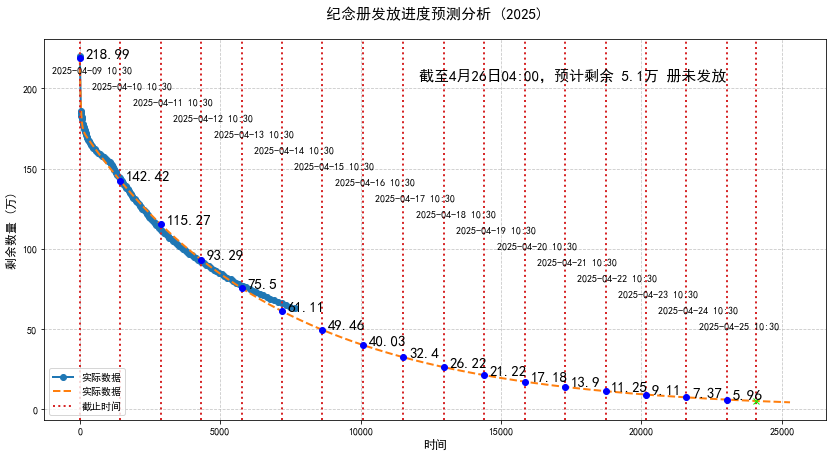

In [22]:
import matplotlib.dates as mdates

# 创建带日期坐标的绘图系统
fig, ax = plt.subplots(figsize=(14, 7))
# 绘制原始数据
ax.plot(time, number, 'o-', color='#1f77b4', linewidth=2, label='实际数据')
# 绘制预测数据
ax.plot(x_pred, y_pred, '--', color='#ff7f0e', linewidth=2, label='实际数据')
# 绘制截止时间戳
ax.axvline(time_max, color='#d62728', linestyle=':', linewidth=2, label='截止时间')
# 间隔时间轴
ytime = 210
for i in range(len(arr)):
    ax.axvline(arr[i], color='#d62728', linestyle=':', linewidth=2)
    plt.text(arr[i]-1000, ytime , timestamp_to_date(arr[i]))
    plt.text(arr[i]+200, lb[i] , round(lb[i],2), size = 15)
    plt.plot(arr[i], lb[i], marker='o', color='b')
    ytime = ytime - 10
# 绘制出数据交点
plt.plot(time_max, result, marker='x', color='lime')
plt.text(time_max-12000, result+200,f"截至4月26日04:00，预计剩余 {result}万 册未发放", size = 15)

# 设置其他图形属性
ax.set_title('纪念册发放进度预测分析 (2025)', fontsize=15, pad=20)
ax.set_xlabel('时间', fontsize=12)
ax.set_ylabel('剩余数量 (万)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='lower left', frameon=True)


# 显示或保存图形
plt.savefig('results.png', dpi=600, bbox_inches='tight')
plt.show()